# NBA Project — Analysis Notebook
Loads the cleaned `master_player_season.csv` and covers:
1. General EDA
2. The project's 5 specific questions (3 descriptive + 2 hypothesis tests)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_csv('../Data/clean_data/master_player_season.csv')
print(df.shape)
df.head(3)


(4266, 32)


,player_id,season_id,team_code,age,games,games_started,minutes,win_shares,ws_per_48,bpm,...,bmi,agility,height_bin,position_id,position_code,mvp_rank,mvp_share,is_mvp_candidate,is_champion,season_name
0,achiupr01,2,MIA,21,61,4,737,1.3,0.085,-4.1,...,26.693198,1.845455,Big-height (201-213cm),1,C,NaN,NaN,False,False,2020-21
1,achiupr01,2,MIA,21,61,4,737,1.3,0.085,-4.1,...,26.693198,1.845455,Big-height (201-213cm),4,PF,NaN,NaN,False,False,2020-21
2,achiupr01,3,TOR,22,73,28,1725,2.5,0.070,-2.6,...,26.693198,1.845455,Big-height (201-213cm),1,C,NaN,NaN,False,False,2021-22


## Part 1 — General EDA

In [2]:
print('Rows:', len(df), '| Unique players:', df['player_id'].nunique(), '| Seasons:', df['season_name'].nunique())
print()
print(df.isna().sum()[df.isna().sum() > 0])


Rows: 4266 | Unique players: 963 | Seasons: 5

birth_date       10
birth_place      10
mvp_rank       4168
mvp_share      4146
dtype: int64


### Distributions of core numeric features

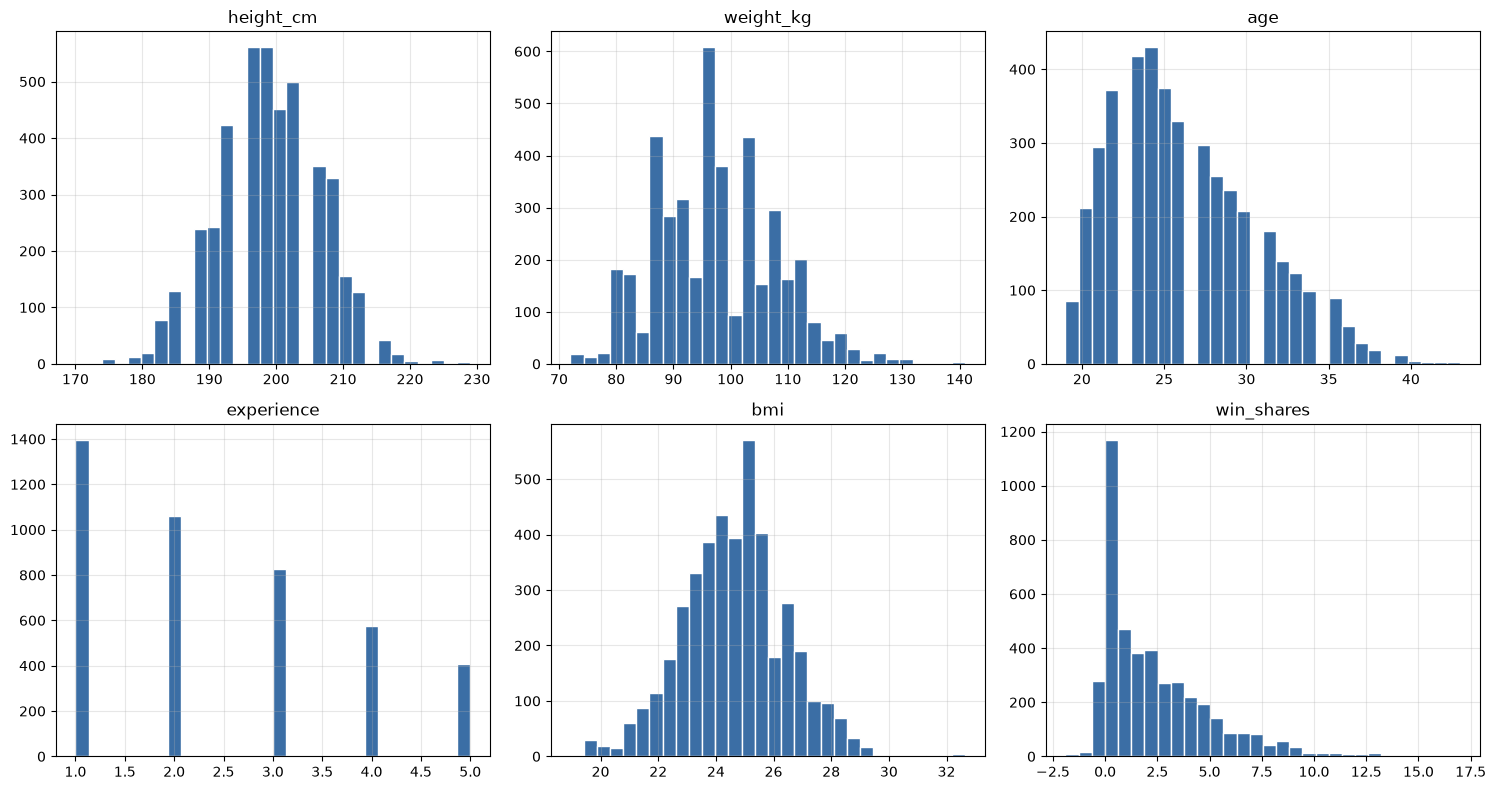

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['height_cm', 'weight_kg', 'age', 'experience', 'bmi', 'win_shares']
for ax, col in zip(axes.flat, cols):
    ax.hist(df[col].dropna(), bins=30, color='#3b6ea5', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=110)
plt.show()


### Position breakdown

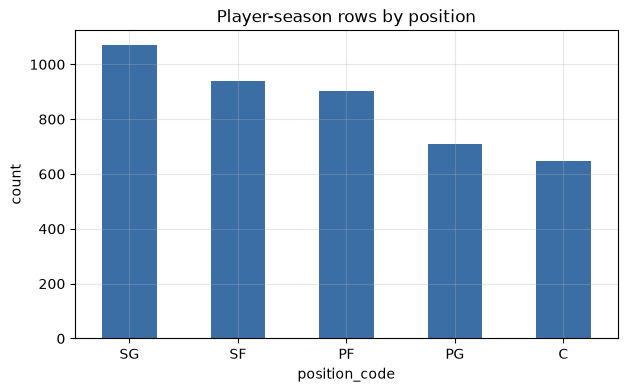

In [4]:
pos_counts = df['position_code'].value_counts()
plt.figure(figsize=(7,4))
pos_counts.plot(kind='bar', color='#3b6ea5')
plt.title('Player-season rows by position')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.savefig('eda_positions.png', dpi=110)
plt.show()


### Correlation heatmap (numeric features)

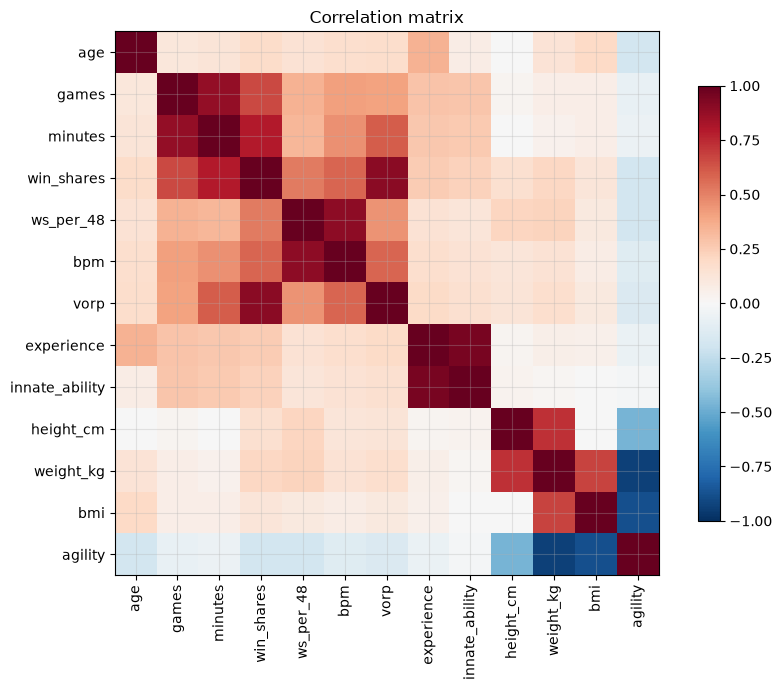

In [5]:
num_cols = ['age','games','minutes','win_shares','ws_per_48','bpm','vorp',
            'experience','innate_ability','height_cm','weight_kg','bmi','agility']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=90)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=110)
plt.show()


### Performance stats by season (are things trending?)

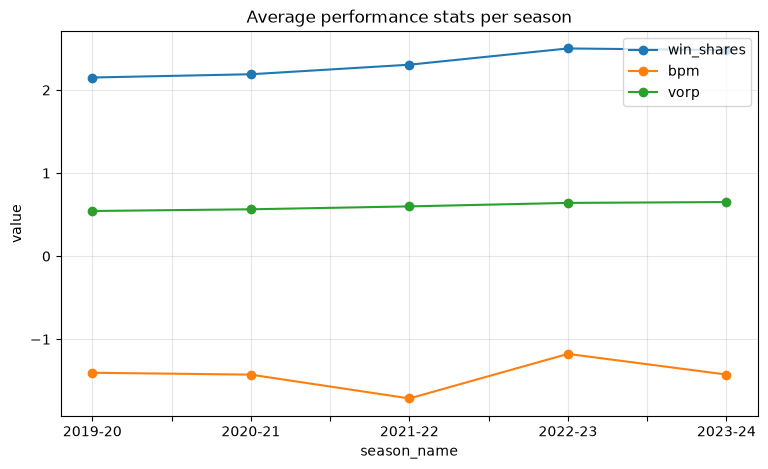

In [6]:
season_avg = df.groupby('season_name')[['win_shares','bpm','vorp']].mean()
season_avg.plot(marker='o')
plt.title('Average performance stats per season')
plt.ylabel('value')
plt.savefig('eda_season_trend.png', dpi=110)
plt.show()


## Part 2 — Project Questions

**Ranking metric used throughout:** `win_shares` is used to define "top N players" per season, since it's a single well-established composite stat available for every row. This is a documented choice, not the only valid one — swap in `vorp` or `bpm` if your team prefers a different metric, and note this assumption in your write-up.

We also exclude `low_sample=True` rows (very low minutes/games) before ranking, so a fluky small-sample stretch doesn't crowd out a genuine top player.

In [7]:
ranking_pool = df[~df['low_sample']].copy()

def top_n_per_season(data, n, metric='win_shares'):
    return (
        data.sort_values(metric, ascending=False)
            .groupby('season_id')
            .head(n)
    )


### Q1 — Height: MJ Trophy (MVP) list vs top-50 players, seasons 2019-20 to 2023-24 (pooled)

MVP-list rows: 120 | Top-50 rows: 250


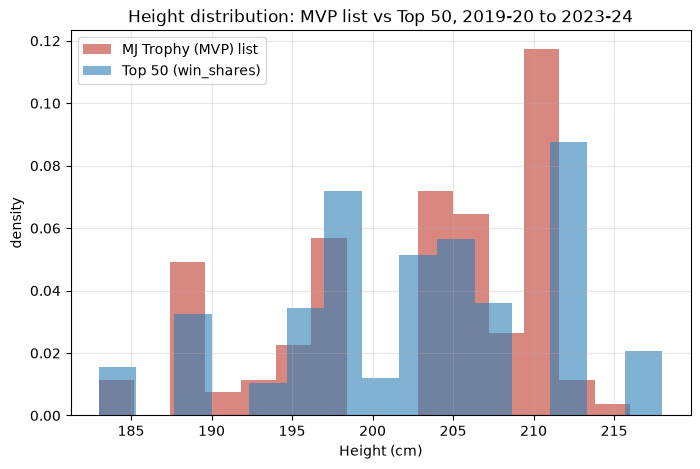

count    120.000000
mean     202.575000
std        8.296666
min      183.000000
25%      198.000000
50%      203.000000
75%      211.000000
max      216.000000
Name: height_cm, dtype: float64

count    250.000000
mean     202.668000
std        8.264562
min      183.000000
25%      198.000000
50%      203.000000
75%      210.250000
max      218.000000
Name: height_cm, dtype: float64


In [8]:
mvp_group = df[df['is_mvp_candidate']]
top50_group = top_n_per_season(ranking_pool, 50)

print('MVP-list rows:', len(mvp_group), '| Top-50 rows:', len(top50_group))

plt.figure(figsize=(8,5))
plt.hist(mvp_group['height_cm'], bins=15, alpha=0.6, label='MJ Trophy (MVP) list', density=True, color='#c0392b')
plt.hist(top50_group['height_cm'], bins=15, alpha=0.6, label='Top 50 (win_shares)', density=True, color='#2c7fb8')
plt.xlabel('Height (cm)'); plt.ylabel('density'); plt.legend()
plt.title('Height distribution: MVP list vs Top 50, 2019-20 to 2023-24')
plt.savefig('q1_height_dist.png', dpi=110)
plt.show()

print(mvp_group['height_cm'].describe())
print()
print(top50_group['height_cm'].describe())


### Q2 — Experience & height: champion active players vs top-15, last two seasons

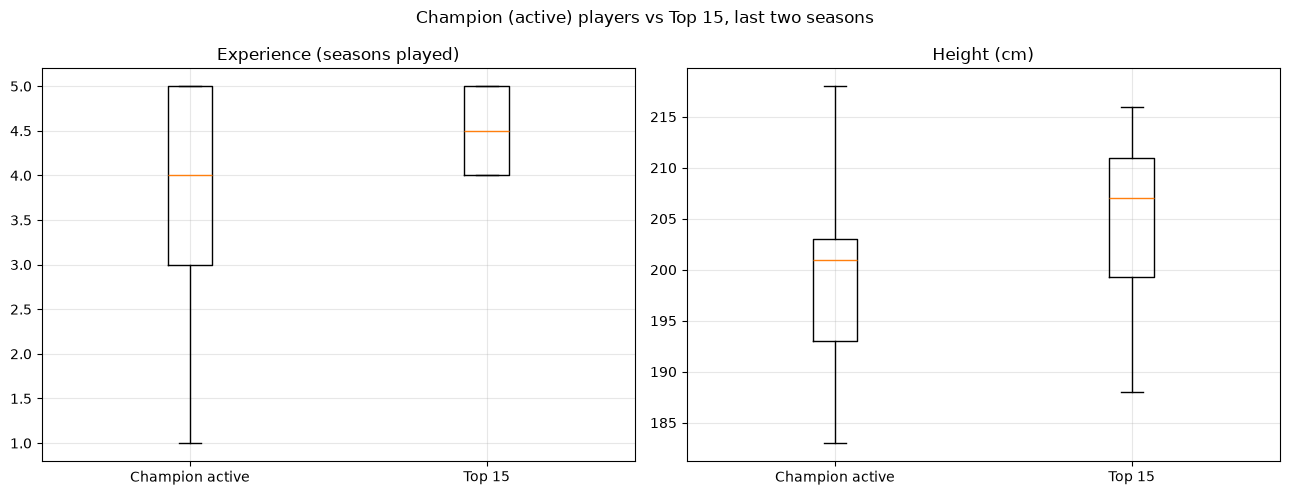

Champion active - experience:
 count    46.000000
mean      3.652174
std       1.385920
min       1.000000
25%       3.000000
50%       4.000000
75%       5.000000
max       5.000000
Name: experience, dtype: float64

Top 15 - experience:
 count    30.000000
mean      4.500000
std       0.508548
min       4.000000
25%       4.000000
50%       4.500000
75%       5.000000
max       5.000000
Name: experience, dtype: float64


In [9]:
last_two = [4, 5]  # 2022-23, 2023-24
champ_active = df[(df['season_id'].isin(last_two)) & (df['is_champion']) & (df['games'] > 0)]
top15 = top_n_per_season(ranking_pool[ranking_pool['season_id'].isin(last_two)], 15)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
for ax, col, title in zip(axes, ['experience','height_cm'], ['Experience (seasons played)','Height (cm)']):
    ax.boxplot([champ_active[col].dropna(), top15[col].dropna()], tick_labels=['Champion active', 'Top 15'])
    ax.set_title(title)
plt.suptitle('Champion (active) players vs Top 15, last two seasons')
plt.tight_layout()
plt.savefig('q2_champ_vs_top15.png', dpi=110)
plt.show()

print('Champion active - experience:\n', champ_active['experience'].describe())
print()
print('Top 15 - experience:\n', top15['experience'].describe())


### Q3 — Point Guard recommendation (based on MJ Trophy / MVP-list appearances, 2019-20 to 2023-24)

In [10]:
pg_mvp = df[(df['position_code'] == 'PG') & (df['is_mvp_candidate'])]

pg_ranking = (
    pg_mvp.groupby(['player_id','full_name'])
          .agg(mvp_appearances=('season_id','nunique'), avg_mvp_share=('mvp_share','mean'))
          .sort_values(['mvp_appearances','avg_mvp_share'], ascending=False)
)

print(pg_ranking.head(10))
print()
print('Top 3 recommendation:')
print(pg_ranking.head(3))


                                   mvp_appearances  avg_mvp_share
player_id full_name                                              
antetgi01 Giannis Antetokounmpo                  5       0.538400
doncilu01 Luka Dončić                            5       0.193600
jamesle01 LeBron James                           3       0.249333
curryst01 Stephen Curry                          3       0.152667
paulch01  Chris Paul                             3       0.055333
gilgesh01 Shai Gilgeous-Alexander                2       0.346000
hardeja01 James Harden                           2       0.182000
brunsja01 Jalen Brunson                          2       0.072000
lillada01 Damian Lillard                         2       0.030500
moranja01 Ja Morant                              2       0.005500

Top 3 recommendation:
                                 mvp_appearances  avg_mvp_share
player_id full_name                                            
antetgi01 Giannis Antetokounmpo                5       0.

### Hypothesis 1 — Agility (height/weight) of top-20 players: has it increased?

Recent group: 2022-23 & 2023-24 (season_id 4,5). Older group: 2020-21 & 2021-22 (season_id 2,3).
We check normality first (Shapiro-Wilk) to decide between an independent t-test and the non-parametric Mann-Whitney U test.

In [11]:
top20 = top_n_per_season(ranking_pool, 20)

recent_agility = top20[top20['season_id'].isin([4,5])]['agility'].dropna()
older_agility  = top20[top20['season_id'].isin([2,3])]['agility'].dropna()

print('Recent (22-23,23-24) n=', len(recent_agility), 'mean=', recent_agility.mean())
print('Older  (20-21,21-22) n=', len(older_agility),  'mean=', older_agility.mean())

# normality check
print('Shapiro recent:', stats.shapiro(recent_agility))
print('Shapiro older :', stats.shapiro(older_agility))


Recent (22-23,23-24) n= 40 mean= 1.9704863207646461
Older  (20-21,21-22) n= 40 mean= 1.9401830222250112
Shapiro recent: ShapiroResult(statistic=np.float64(0.9203438241108669), pvalue=np.float64(0.007895326167195479))
Shapiro older : ShapiroResult(statistic=np.float64(0.9184213712538579), pvalue=np.float64(0.006871632976271264))


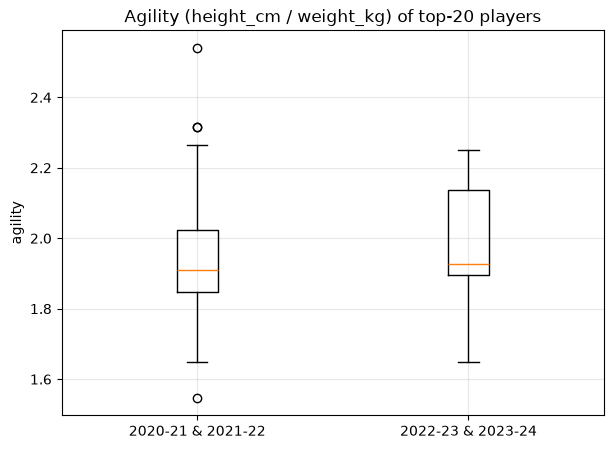

In [12]:
fig, ax = plt.subplots(figsize=(7,5))
ax.boxplot([older_agility, recent_agility], tick_labels=['2020-21 & 2021-22', '2022-23 & 2023-24'])
ax.set_title('Agility (height_cm / weight_kg) of top-20 players')
ax.set_ylabel('agility')
plt.savefig('h1_agility_boxplot.png', dpi=110)
plt.show()


In [13]:
# Choose test based on normality result above.
# If BOTH groups look normal (p > 0.05 on Shapiro) -> Welch's t-test (unequal variance assumed by default, robust choice)
# If either group fails normality -> Mann-Whitney U (non-parametric)

shapiro_recent_p = stats.shapiro(recent_agility).pvalue
shapiro_older_p  = stats.shapiro(older_agility).pvalue

if shapiro_recent_p > 0.05 and shapiro_older_p > 0.05:
    stat, p = stats.ttest_ind(recent_agility, older_agility, equal_var=False)
    test_used = "Welch's t-test"
else:
    stat, p = stats.mannwhitneyu(recent_agility, older_agility, alternative='two-sided')
    test_used = 'Mann-Whitney U'

print(f'Test used: {test_used}')
print(f'statistic={stat:.4f}, p-value={p:.4f}')

# effect size: Cohen's d regardless of which test, for interpretability
pooled_std = np.sqrt(((len(recent_agility)-1)*recent_agility.std()**2 +
                       (len(older_agility)-1)*older_agility.std()**2) /
                      (len(recent_agility)+len(older_agility)-2))
cohens_d = (recent_agility.mean() - older_agility.mean()) / pooled_std
print(f"Cohen's d: {cohens_d:.3f}")

alpha = 0.05
if p < alpha:
    direction = 'increased' if recent_agility.mean() > older_agility.mean() else 'decreased'
    print(f'Result: statistically significant difference (p<{alpha}) -- agility appears to have {direction}.')
else:
    print(f'Result: not statistically significant at alpha={alpha} -- no reliable evidence of a change in agility.')


Test used: Mann-Whitney U
statistic=957.0000, p-value=0.1309
Cohen's d: 0.168
Result: not statistically significant at alpha=0.05 -- no reliable evidence of a change in agility.


### Hypothesis 2 — Innate ability (experience/age) of champion active players: has it increased?

Recent group: last two seasons (4,5). Comparison group: the two seasons before that (2,3). Active champion-team players only (`games > 0`).

In [14]:
champ_recent = df[(df['season_id'].isin([4,5])) & (df['is_champion']) & (df['games']>0)]['innate_ability'].dropna()
champ_older  = df[(df['season_id'].isin([2,3])) & (df['is_champion']) & (df['games']>0)]['innate_ability'].dropna()

print('Recent n=', len(champ_recent), 'mean=', champ_recent.mean())
print('Older  n=', len(champ_older),  'mean=', champ_older.mean())

print('Shapiro recent:', stats.shapiro(champ_recent))
print('Shapiro older :', stats.shapiro(champ_older))


Recent n= 46 mean= 0.13446616670346134
Older  n= 53 mean= 0.0807393990250562
Shapiro recent: ShapiroResult(statistic=np.float64(0.9223708322219775), pvalue=np.float64(0.004536326452441404))
Shapiro older : ShapiroResult(statistic=np.float64(0.9663278943366547), pvalue=np.float64(0.13958891887953034))


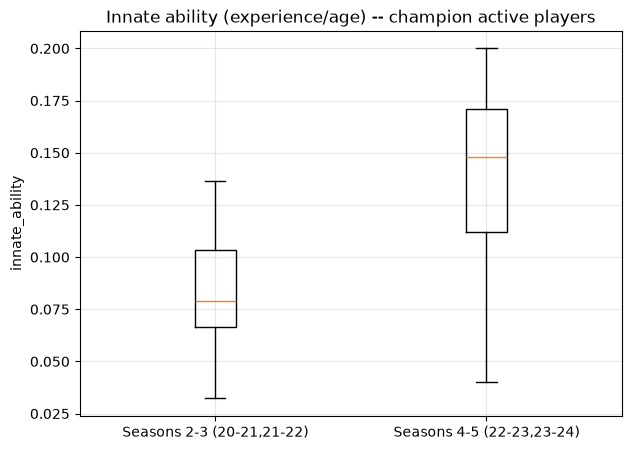

In [15]:
fig, ax = plt.subplots(figsize=(7,5))
ax.boxplot([champ_older, champ_recent], tick_labels=['Seasons 2-3 (20-21,21-22)', 'Seasons 4-5 (22-23,23-24)'])
ax.set_title('Innate ability (experience/age) -- champion active players')
ax.set_ylabel('innate_ability')
plt.savefig('h2_innate_ability_boxplot.png', dpi=110)
plt.show()


In [16]:
shapiro_recent_p = stats.shapiro(champ_recent).pvalue
shapiro_older_p  = stats.shapiro(champ_older).pvalue

if shapiro_recent_p > 0.05 and shapiro_older_p > 0.05:
    stat, p = stats.ttest_ind(champ_recent, champ_older, equal_var=False)
    test_used = "Welch's t-test"
else:
    stat, p = stats.mannwhitneyu(champ_recent, champ_older, alternative='two-sided')
    test_used = 'Mann-Whitney U'

print(f'Test used: {test_used}')
print(f'statistic={stat:.4f}, p-value={p:.4f}')

pooled_std = np.sqrt(((len(champ_recent)-1)*champ_recent.std()**2 +
                       (len(champ_older)-1)*champ_older.std()**2) /
                      (len(champ_recent)+len(champ_older)-2))
cohens_d = (champ_recent.mean() - champ_older.mean()) / pooled_std
print(f"Cohen's d: {cohens_d:.3f}")

alpha = 0.05
if p < alpha:
    direction = 'increased' if champ_recent.mean() > champ_older.mean() else 'decreased'
    print(f'Result: statistically significant (p<{alpha}) -- innate ability appears to have {direction}.')
else:
    print(f'Result: not statistically significant at alpha={alpha} -- no reliable evidence of a change.')


Test used: Mann-Whitney U
statistic=2029.5000, p-value=0.0000
Cohen's d: 1.424
Result: statistically significant (p<0.05) -- innate ability appears to have increased.
